# Laporan Analisa Data Menggunakan Naive Bayes


## 1. Deskripsi Proyek

Proyek ini digunakan untuk membuat analisis data menggunakan algoritma **Naive Bayes**. Implementasi model dilakukan melalui **Python Script** di KNIME, sehingga proses klasifikasi tidak menggunakan node klasifikasi bawaan KNIME seperti **Naive Bayes Learner** atau **Naive Bayes Predictor**.

Dataset yang digunakan bersifat bebas. Pada proyek ini, dataset yang digunakan adalah data prediksi kelulusan mahasiswa. Data tersebut memuat empat fitur utama, yaitu `jam_belajar`, `kehadiran`, `nilai_tugas`, dan `ikut_bimbingan`. Target klasifikasi berada pada kolom `status_lulus`, dengan dua kelas, yaitu `lulus` dan `tidak`.

Proyek ini termasuk dalam kategori **supervised learning** karena data training sudah memiliki label kelas. Model dilatih berdasarkan data yang sudah memiliki label, lalu model digunakan untuk memprediksi kelas pada data testing.



## 2. Dasar Teori Singkat

### 2.1 Supervised Learning dan Klasifikasi

**Supervised learning** adalah metode pembelajaran mesin yang menggunakan data training dengan label kelas. Model mempelajari hubungan antara fitur dan label kelas, kemudian menggunakan pola tersebut untuk mengklasifikasikan data baru.

Dalam proyek ini, label kelas terdapat pada kolom `status_lulus`. Karena target yang diprediksi berupa kelas diskrit, yaitu `lulus` dan `tidak`, maka proyek ini termasuk tugas **klasifikasi**. Klasifikasi berbeda dari prediksi nilai kontinu karena klasifikasi menghasilkan label kelas, sedangkan prediksi kontinu menghasilkan nilai numerik.

### 2.2 Naive Bayes Classifier

**Naive Bayes Classifier** adalah algoritma klasifikasi berbasis probabilitas yang menggunakan Teorema Bayes. Model ini menghitung peluang suatu data masuk ke kelas tertentu berdasarkan nilai fitur yang dimiliki data tersebut.

Rumus dasar Teorema Bayes adalah:

$$
P(C_i|X) = \frac{P(X|C_i) \times P(C_i)}{P(X)}
$$

Keterangan:

| Simbol | Keterangan |
|---|---|
| $P(C_i|X)$ | Probabilitas posterior kelas $C_i$ setelah data $X$ diketahui |
| $P(X|C_i)$ | Likelihood, yaitu peluang data $X$ muncul pada kelas $C_i$ |
| $P(C_i)$ | Prior, yaitu peluang awal kelas $C_i$ |
| $P(X)$ | Evidence, yaitu peluang data $X$ |

Karena $P(X)$ bernilai sama untuk semua kelas, proses klasifikasi cukup membandingkan nilai:

$$
P(X|C_i) \times P(C_i)
$$

Kelas dengan nilai terbesar dipilih sebagai hasil prediksi.

### 2.3 Asumsi Independensi

Naive Bayes memiliki asumsi bahwa setiap fitur saling bebas atau **independent** terhadap fitur lain dalam satu kelas. Artinya, model menganggap fitur `jam_belajar`, `kehadiran`, `nilai_tugas`, dan `ikut_bimbingan` tidak saling bergantung ketika menghitung probabilitas kelas.

Asumsi ini membuat Naive Bayes sederhana dan cepat digunakan. Namun, pada data nyata, fitur-fitur tersebut dapat saling berhubungan. Misalnya, mahasiswa dengan kehadiran tinggi bisa saja memiliki nilai tugas yang lebih baik. Oleh karena itu, hasil model tetap perlu dianalisis secara hati-hati.

### 2.4 Laplace Smoothing

Naive Bayes dapat mengalami masalah probabilitas nol jika suatu kategori tidak pernah muncul pada kelas tertentu di data training. Untuk mengatasi masalah ini, digunakan **Laplace smoothing**.

Pada proyek ini, Laplace smoothing diterapkan melalui parameter:

```python
CategoricalNB(alpha=1.0)
```

Nilai `alpha=1.0` membantu mencegah nilai probabilitas menjadi nol, sehingga model tetap dapat menghitung peluang pada kategori yang jarang muncul.



## 3. Dataset

Dataset yang digunakan terdiri dari 30 data mahasiswa. Variabel yang digunakan dapat dilihat pada tabel berikut.

| Nama Kolom | Keterangan | Jenis Data |
|---|---|---|
| `jam_belajar` | Kategori waktu belajar mahasiswa | Kategorikal |
| `kehadiran` | Kategori tingkat kehadiran mahasiswa | Kategorikal |
| `nilai_tugas` | Kategori nilai tugas mahasiswa | Kategorikal |
| `ikut_bimbingan` | Status keikutsertaan bimbingan | Kategorikal |
| `status_lulus` | Target klasifikasi | Kategorikal |

Nilai pada fitur berbentuk kategori seperti `rendah`, `sedang`, `tinggi`, `ya`, dan `tidak`. Karena fitur berbentuk kategorikal, model yang digunakan adalah **Categorical Naive Bayes** melalui class `CategoricalNB` dari `sklearn.naive_bayes`.

Model `CategoricalNB` lebih sesuai dibandingkan `GaussianNB` karena `GaussianNB` digunakan untuk fitur numerik kontinu yang diasumsikan mengikuti distribusi Gaussian.



## 4. Tahap Data Preparation

Sebelum model dilatih, data diproses melalui beberapa tahap.

| Tahap | Penjelasan |
|---|---|
| Membuat dataset | Dataset dibuat langsung di dalam script Python |
| Memisahkan fitur dan target | Fitur disimpan pada variabel `X`, sedangkan target disimpan pada variabel `y` |
| Membagi data | Data dibagi menjadi data training dan testing dengan rasio 70:30 |
| Transformasi data | Data kategorikal diubah menjadi angka menggunakan `OrdinalEncoder` |
| Melatih model | Model `CategoricalNB` dilatih menggunakan data training |
| Evaluasi model | Model dievaluasi menggunakan accuracy, precision, recall, F1-score, dan confusion matrix |

Transformasi data diperlukan karena model pada `scikit-learn` memproses data dalam bentuk numerik. Oleh karena itu, kategori seperti `rendah`, `sedang`, `tinggi`, `ya`, dan `tidak` dikodekan menjadi angka sebelum masuk ke model.



## 5. Workflow KNIME

Workflow KNIME yang digunakan hanya terdiri dari satu node, yaitu:

```text
Python Script
```

Node tersebut digunakan untuk menjalankan seluruh proses analisis, mulai dari pembuatan dataset, pelatihan model, prediksi, evaluasi, sampai pengiriman hasil ke output table KNIME.

Penggunaan satu node ini sesuai dengan ketentuan tugas karena model classifier dibuat menggunakan script Python dan library `scikit-learn`, bukan menggunakan node klasifikasi bawaan KNIME.


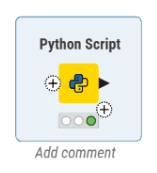


## 6. Kode Program

Kode berikut merupakan script yang digunakan pada node **Python Script** di KNIME.



In [2]:
# ==========================================================
# Prediksi kelulusan mahasiswa
# ==========================================================

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ==========================================================
# 1. MEMBUAT DATASET
# ==========================================================

data = {
    "jam_belajar": [
        "rendah","rendah","sedang","tinggi","tinggi","sedang","rendah","tinggi","sedang","rendah",
        "tinggi","sedang","tinggi","rendah","sedang","tinggi","rendah","sedang","tinggi","sedang",
        "rendah","tinggi","sedang","rendah","tinggi","sedang","tinggi","rendah","sedang","tinggi"
    ],
    "kehadiran": [
        "rendah","sedang","sedang","tinggi","tinggi","tinggi","rendah","tinggi","sedang","rendah",
        "tinggi","sedang","tinggi","sedang","tinggi","tinggi","rendah","sedang","tinggi","tinggi",
        "sedang","tinggi","rendah","rendah","tinggi","sedang","tinggi","sedang","tinggi","tinggi"
    ],
    "nilai_tugas": [
        "rendah","rendah","sedang","tinggi","sedang","tinggi","rendah","tinggi","sedang","rendah",
        "tinggi","sedang","tinggi","rendah","tinggi","tinggi","sedang","sedang","tinggi","sedang",
        "rendah","tinggi","sedang","rendah","tinggi","sedang","tinggi","rendah","tinggi","tinggi"
    ],
    "ikut_bimbingan": [
        "tidak","tidak","ya","ya","ya","ya","tidak","ya","tidak","tidak",
        "ya","ya","ya","tidak","ya","ya","tidak","ya","ya","tidak",
        "tidak","ya","ya","tidak","ya","tidak","ya","tidak","ya","ya"
    ],
    "status_lulus": [
        "tidak","tidak","lulus","lulus","lulus","lulus","tidak","lulus","lulus","tidak",
        "lulus","lulus","lulus","tidak","lulus","lulus","tidak","lulus","lulus","lulus",
        "tidak","lulus","tidak","tidak","lulus","lulus","lulus","tidak","lulus","lulus"
    ]
}
df = pd.DataFrame(data)


# ==========================================================
# 2. MEMISAHKAN FITUR DAN TARGET
# ==========================================================

X = df.drop(columns=["status_lulus"])
y = df["status_lulus"]


# ==========================================================
# 3. MEMBAGI DATA TRAINING DAN TESTING
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ==========================================================
# 4. MEMBUAT DAN MELATIH MODEL NAIVE BAYES
# ==========================================================

model = Pipeline([
    ("encoder", OrdinalEncoder(dtype=int)),
    ("classifier", CategoricalNB(alpha=1.0))
])

model.fit(X_train, y_train)


# ==========================================================
# 5. MELAKUKAN PREDIKSI
# ==========================================================

y_pred = model.predict(X_test)


# ==========================================================
# 6. EVALUASI MODEL
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="lulus", zero_division=0)
recall = recall_score(y_test, y_pred, pos_label="lulus", zero_division=0)
f1 = f1_score(y_test, y_pred, pos_label="lulus", zero_division=0)

cm = confusion_matrix(y_test, y_pred, labels=["lulus", "tidak"])


# ==========================================================
# 7. MEMBUAT TABEL HASIL
# ==========================================================

hasil_prediksi = X_test.copy().reset_index(drop=True)
hasil_prediksi["actual"] = y_test.values
hasil_prediksi["prediction"] = y_pred
hasil_prediksi["status_prediksi"] = hasil_prediksi.apply(
    lambda row: "Benar" if row["actual"] == row["prediction"] else "Salah",
    axis=1
)

ringkasan = pd.DataFrame({
    "jam_belajar": ["", "", "", ""],
    "kehadiran": ["", "", "", ""],
    "nilai_tugas": ["", "", "", ""],
    "ikut_bimbingan": ["", "", "", ""],
    "actual": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "prediction": [accuracy, precision, recall, f1],
    "status_prediksi": ["", "", "", ""]
})

confusion = pd.DataFrame({
    "jam_belajar": ["", "", "", ""],
    "kehadiran": ["", "", "", ""],
    "nilai_tugas": ["", "", "", ""],
    "ikut_bimbingan": ["", "", "", ""],
    "actual": [
        "True Lulus",
        "Lulus diprediksi Tidak",
        "Tidak diprediksi Lulus",
        "True Tidak"
    ],
    "prediction": [cm[0][0], cm[0][1], cm[1][0], cm[1][1]],
    "status_prediksi": ["", "", "", ""]
})

output = pd.concat([hasil_prediksi, ringkasan, confusion], ignore_index=True)

# Mengubah semua kolom menjadi string agar aman dibaca KNIME
output = output.astype(str)


# ==========================================================
# 8. MENAMPILKAN OUTPUT
# ==========================================================
# Di KNIME, output dikirim ke output table.
# Di Jupyter Notebook/Jupyter Book, output ditampilkan dengan display().

try:
    import knime.scripting.io as knio
    knio.output_tables[0] = knio.Table.from_pandas(output)
except Exception:
    display(output)

,jam_belajar,kehadiran,nilai_tugas,ikut_bimbingan,actual,prediction,status_prediksi
0,tinggi,tinggi,tinggi,ya,lulus,lulus,Benar
1,tinggi,tinggi,tinggi,ya,lulus,lulus,Benar
2,sedang,sedang,sedang,ya,lulus,lulus,Benar
3,rendah,rendah,rendah,tidak,tidak,tidak,Benar
4,tinggi,tinggi,tinggi,ya,lulus,lulus,Benar
5,rendah,sedang,rendah,tidak,tidak,tidak,Benar
6,tinggi,tinggi,tinggi,ya,lulus,lulus,Benar
7,tinggi,tinggi,tinggi,ya,lulus,lulus,Benar
8,rendah,sedang,rendah,tidak,tidak,tidak,Benar
9,,,,,Accuracy,1.0,


## 7. Hasil Output KNIME

Berdasarkan hasil eksekusi pada KNIME, node **Python Script** berhasil dijalankan. Tabel output yang muncul memiliki:

```text
Rows    : 17
Columns : 7
```

Baris pertama sampai baris kesembilan berisi hasil prediksi terhadap data testing. Baris berikutnya berisi nilai evaluasi model dan hasil confusion matrix.

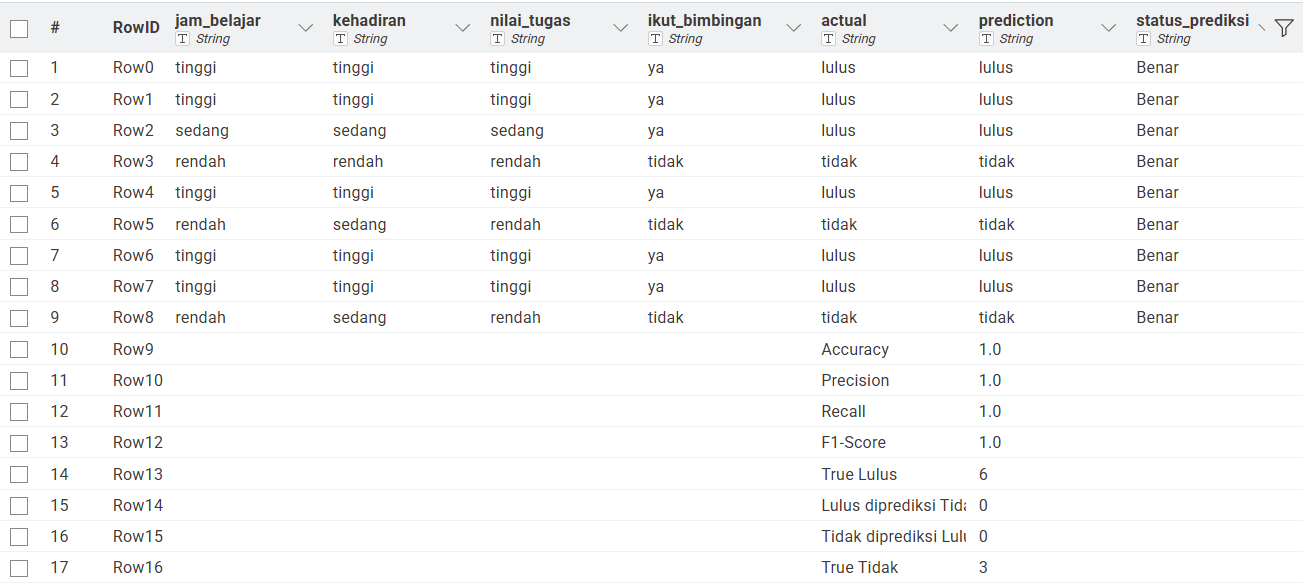

## 8. Ringkasan Hasil Prediksi

Ringkasan hasil prediksi pada data testing adalah sebagai berikut.

| Data Uji | Actual | Prediction | Status |
|---:|---|---|---|
| 1 | lulus | lulus | Benar |
| 2 | lulus | lulus | Benar |
| 3 | lulus | lulus | Benar |
| 4 | tidak | tidak | Benar |
| 5 | lulus | lulus | Benar |
| 6 | tidak | tidak | Benar |
| 7 | lulus | lulus | Benar |
| 8 | lulus | lulus | Benar |
| 9 | tidak | tidak | Benar |

Seluruh data testing berhasil diprediksi dengan benar. Tidak terdapat hasil prediksi yang salah pada data testing.



## 9. Evaluasi Model

Hasil evaluasi model adalah sebagai berikut.

| Metrik Evaluasi | Nilai |
|---|---:|
| Accuracy | 1.0 |
| Precision | 1.0 |
| Recall | 1.0 |
| F1-Score | 1.0 |

### Interpretasi Evaluasi

**Accuracy** bernilai 1.0, artinya seluruh data testing berhasil diklasifikasikan dengan benar. Dengan kata lain, model memiliki tingkat ketepatan sebesar 100% pada data testing.

**Precision** bernilai 1.0, artinya seluruh data yang diprediksi sebagai kelas `lulus` benar-benar termasuk kelas `lulus`.

**Recall** bernilai 1.0, artinya seluruh data aktual yang termasuk kelas `lulus` berhasil dikenali oleh model.

**F1-score** bernilai 1.0, artinya model memiliki keseimbangan yang baik antara precision dan recall pada data testing.



## 10. Confusion Matrix

Hasil confusion matrix adalah sebagai berikut.

| Keterangan | Nilai |
|---|---:|
| True Lulus | 6 |
| Lulus diprediksi Tidak | 0 |
| Tidak diprediksi Lulus | 0 |
| True Tidak | 3 |

### Interpretasi Confusion Matrix

Terdapat 6 data dengan kelas aktual `lulus` yang berhasil diprediksi sebagai `lulus`. Selain itu, terdapat 3 data dengan kelas aktual `tidak` yang berhasil diprediksi sebagai `tidak`.

Tidak terdapat data `lulus` yang salah diprediksi sebagai `tidak`. Tidak terdapat pula data `tidak` yang salah diprediksi sebagai `lulus`. Hal ini menunjukkan bahwa model bekerja sangat baik pada dataset testing yang digunakan.



## 11. Analisis Hasil

Berdasarkan hasil output KNIME, model **Naive Bayes** berhasil melakukan klasifikasi terhadap data prediksi kelulusan mahasiswa. Model menggunakan empat fitur kategorikal, yaitu `jam_belajar`, `kehadiran`, `nilai_tugas`, dan `ikut_bimbingan`. Keempat fitur tersebut digunakan untuk memprediksi target `status_lulus`.

Nilai evaluasi menunjukkan bahwa model memperoleh accuracy, precision, recall, dan F1-score sebesar 1.0. Hasil ini menunjukkan bahwa seluruh data testing berhasil diklasifikasikan dengan benar. Pada confusion matrix, model berhasil mengenali 6 data `lulus` dan 3 data `tidak` tanpa kesalahan prediksi.

Hasil tersebut menunjukkan bahwa pola pada dataset contoh cukup jelas bagi model. Mahasiswa dengan pola `jam_belajar`, `kehadiran`, `nilai_tugas`, dan `ikut_bimbingan` tertentu dapat diklasifikasikan secara tepat oleh model Naive Bayes.

Namun, hasil 100% tidak boleh langsung dianggap sebagai bukti bahwa model selalu sempurna. Dataset yang digunakan masih kecil dan bersifat contoh. Pada data nyata yang lebih besar, variasi data dapat lebih kompleks, sehingga nilai evaluasi model dapat berubah. Selain itu, Naive Bayes memiliki asumsi bahwa setiap fitur saling bebas, padahal dalam kasus nyata fitur seperti kehadiran dan nilai tugas dapat saling berkaitan.



## 12. Kelebihan dan Keterbatasan Model

### 12.1 Kelebihan

1. Model sederhana dan mudah diimplementasikan.
2. Proses training relatif cepat.
3. Cocok untuk data kategorikal jika menggunakan `CategoricalNB`.
4. Dapat digunakan langsung dalam Python Script di KNIME.
5. Memiliki hasil evaluasi yang baik pada dataset contoh.

### 12.2 Keterbatasan

1. Model mengasumsikan bahwa setiap fitur saling bebas.
2. Dataset yang digunakan masih kecil.
3. Hasil evaluasi 100% belum tentu berlaku pada data nyata berskala besar.
4. Hubungan antarfitur belum dimodelkan secara kompleks.
5. Model perlu diuji ulang jika digunakan pada data mahasiswa yang lebih banyak dan bervariasi.



## 13. Kesimpulan

Berdasarkan proyek yang telah dilakukan, dapat disimpulkan bahwa analisis data menggunakan **Naive Bayes** berhasil dilakukan melalui **Python Script** di KNIME. Model dibuat menggunakan library `scikit-learn`, khususnya class `CategoricalNB` dari modul `sklearn.naive_bayes`.

Dataset yang digunakan adalah data bebas berupa prediksi kelulusan mahasiswa. Seluruh fitur pada dataset berbentuk kategorikal, sehingga pemilihan `CategoricalNB` sudah sesuai. Proses data preparation dilakukan melalui pemisahan fitur dan target, pembagian data training-testing, serta encoding data kategorikal menggunakan `OrdinalEncoder`.

Hasil evaluasi menunjukkan bahwa model memperoleh nilai accuracy, precision, recall, dan F1-score sebesar 1.0. Confusion matrix menunjukkan bahwa 6 data `lulus` dan 3 data `tidak` berhasil diklasifikasikan dengan benar. Dengan demikian, model berhasil bekerja dengan baik pada dataset contoh.

Walaupun hasil evaluasi sangat baik, model tetap memiliki keterbatasan karena dataset masih kecil dan Naive Bayes memiliki asumsi independensi antarfitur. Oleh karena itu, untuk penggunaan pada kasus nyata, model perlu diuji dengan data yang lebih besar dan lebih bervariasi.

